# [LAB11] 지도학습 > 시계열 분석 > 비트코인시세 시계열분석

## 📘 #01. 준비작업

### 📝 [1] 패키지 참조

In [2]:
from hossam import *
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import datetime as dt
from pandas import to_datetime, DataFrame, date_range, concat
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import holidays
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
# 로딩바
from tqdm.auto import tqdm
# 비트코인 시세 데이터 수집 모듈
import pyupbit

## 📘 #02. 비트코인 시세 데이터

### 📝 [1] 조회 가능한 단위 확인

- KRW : 한국화폐
- BTC : Bitcoin
- ETH : 이더리움
- • • •

In [3]:
print(pyupbit.get_tickers())

['BTC-BERA', 'BTC-FIL', 'BTC-SIGN', 'BTC-VIRTUAL', 'BTC-BAT', 'KRW-WAXP', 'USDT-PEPE', 'BTC-BAR', 'USDT-WCT', 'KRW-CARV', 'KRW-LSK', 'USDT-DOGE', 'KRW-0G', 'USDT-AXL', 'USDT-YGG', 'BTC-SCR', 'USDT-JASMY', 'BTC-WLD', 'BTC-VANA', 'BTC-LWA', 'BTC-DGB', 'USDT-BONK', 'BTC-BCH', 'BTC-JASMY', 'KRW-BORA', 'KRW-PUNDIX', 'BTC-ORBS', 'USDT-WAL', 'KRW-USD1', 'USDT-WLFI', 'KRW-BAT', 'USDT-ZK', 'USDT-NOM', 'KRW-HUNT', 'KRW-PENGU', 'KRW-FIL', 'BTC-ANIME', 'BTC-ORCA', 'KRW-BEAM', 'BTC-SOON', 'BTC-ELSA', 'BTC-LRC', 'KRW-DOOD', 'BTC-TOKAMAK', 'BTC-SOPH', 'BTC-STRAX', 'KRW-WAVES', 'KRW-USDC', 'KRW-MOVE', 'KRW-TREE', 'BTC-GLMR', 'KRW-USDE', 'KRW-AERGO', 'KRW-WET', 'KRW-USDT', 'BTC-LSK', 'USDT-RENDER', 'BTC-SOMI', 'USDT-RESOLV', 'KRW-2Z', 'BTC-STEEM', 'USDT-LPT', 'KRW-BOUNTY', 'KRW-KAITO', 'USDT-WET', 'KRW-LPT', 'BTC-PROVE', 'BTC-DEEP', 'BTC-WET', 'USDT-ARPA', 'BTC-INIT', 'BTC-LPT', 'BTC-BREV', 'BTC-POLYX', 'KRW-BLAST', 'USDT-ANIME', 'USDT-USDE', 'USDT-USDC', 'USDT-TREE', 'BTC-BIO', 'USDT-WLD', 'BTC-BIRB',

### 📝 [2] 특정 단어를 포함하는 조회 가능 목록만 가져오기

In [4]:
print(pyupbit.get_tickers(fiat='KRW'))

['KRW-WAXP', 'KRW-CARV', 'KRW-LSK', 'KRW-0G', 'KRW-BORA', 'KRW-PUNDIX', 'KRW-USD1', 'KRW-BAT', 'KRW-HUNT', 'KRW-PENGU', 'KRW-FIL', 'KRW-BEAM', 'KRW-DOOD', 'KRW-WAVES', 'KRW-USDC', 'KRW-MOVE', 'KRW-TREE', 'KRW-USDE', 'KRW-AERGO', 'KRW-WET', 'KRW-USDT', 'KRW-2Z', 'KRW-BOUNTY', 'KRW-KAITO', 'KRW-LPT', 'KRW-BLAST', 'KRW-DKA', 'KRW-ANKR', 'KRW-ALGO', 'KRW-SHIB', 'KRW-UNI', 'KRW-BIO', 'KRW-WLFI', 'KRW-TOKAMAK', 'KRW-CYBER', 'KRW-SKR', 'KRW-DOGE', 'KRW-WLD', 'KRW-PEPE', 'KRW-HBAR', 'KRW-BCH', 'KRW-NEWT', 'KRW-SEI', 'KRW-BONK', 'KRW-JST', 'KRW-AAVE', 'KRW-JTO', 'KRW-JUP', 'KRW-FLOW', 'KRW-ALT', 'KRW-LAYER', 'KRW-TRX', 'KRW-POWR', 'KRW-ATOM', 'KRW-ARKM', 'KRW-CRO', 'KRW-NXPC', 'KRW-A', 'KRW-TRUMP', 'KRW-F', 'KRW-G', 'KRW-CELO', 'KRW-AERO', 'KRW-CTC', 'KRW-ANIME', 'KRW-APT', 'KRW-MOCA', 'KRW-API3', 'KRW-AHT', 'KRW-EGLD', 'KRW-ERA', 'KRW-FF', 'KRW-PLUME', 'KRW-ESP', 'KRW-NEO', 'KRW-ETC', 'KRW-IOTA', 'KRW-IOST', 'KRW-AKT', 'KRW-COW', 'KRW-VIRTUAL', 'KRW-ETH', 'KRW-IQ', 'KRW-IP', 'KRW-NEAR', 'KRW-R

### 📝 [3] 현재 시세 가져오기

조회하고자 하는 단위의 이름을 리스트로 설정한다.

In [5]:
pyupbit.get_current_price(["KRW-BTC", "KRW-ETH"])

{'KRW-BTC': 95359000.0, 'KRW-ETH': 2762000.0}

### 📝 [4] 특정 기간에 대한 시세 데이터 가져오기

비트코인의 한국 화폐단위( KRW-BTC ) 데이터를 오늘 날짜부터 500일간 일단위( day )로 조회

**조회간격 단위:** minute1 , minute3 , minute5 , minute10 , minute15 , minute30 , minute60 , minute240 , day , week , month

| 필드 | 설명 |
|------|------|
| open | 시가 |
| high | 고가 |
| low | 저가 |
| close | 종가 |
| volume | 거래량 |
| value | 거래량을 지정된 화폐 단위로 환산한 가치 |

In [6]:
# 한국 비트코인 시세 데이터 수집
ticker = 'KRW-BTC'
# 오늘부터 시작
to = dt.datetime.now().strftime('%Y-%m-%d')
# 1년치 데이터 수집
count = 365
# 일단위 데이터
interval = 'day'
origin = pyupbit.get_ohlcv(ticker=ticker, interval=interval, to=to, count=count)
origin.head()

,open,high,low,close,volume,value
2025-02-25 09:00:00,132135000.000,134899000.000,125004000.000,129715000.000,9063.168,1173142441896.490
2025-02-26 09:00:00,129715000.000,130000000.000,120723000.000,122784000.000,4911.988,616121443775.913
2025-02-27 09:00:00,122775000.000,127493000.000,121500000.000,124331000.000,3832.783,477534913336.857
2025-02-28 09:00:00,124404000.000,125411000.000,116504000.000,124499000.000,8051.742,968879646102.795
2025-03-01 09:00:00,124499000.000,128980000.000,123342000.000,128320000.000,3200.778,405122480757.343


## 📘 #03. 데이터 전처리

### 📝 [1] 시세가격에 대한 파생변수 추가

최고가와 최저가의 평균을 그날의 시세가격으로 삼기로 결정하고 데이터 전처리를 수행

In [7]:
df1 = origin.copy()
df1['price'] = (df1['high'] + df1['low']) / 2
df1.head()

,open,high,low,close,volume,value,price
2025-02-25 09:00:00,132135000.000,134899000.000,125004000.000,129715000.000,9063.168,1173142441896.490,129951500.000
2025-02-26 09:00:00,129715000.000,130000000.000,120723000.000,122784000.000,4911.988,616121443775.913,125361500.000
2025-02-27 09:00:00,122775000.000,127493000.000,121500000.000,124331000.000,3832.783,477534913336.857,124496500.000
2025-02-28 09:00:00,124404000.000,125411000.000,116504000.000,124499000.000,8051.742,968879646102.795,120957500.000
2025-03-01 09:00:00,124499000.000,128980000.000,123342000.000,128320000.000,3200.778,405122480757.343,126161000.000


### 📝 [2] Prophet에 적용할 데이터로 구성

In [8]:
df2 = df1[['price']].copy()
df2.reset_index(inplace=True)
df2.rename(columns={"index": "ds", "price": "y"}, inplace=True)
df2.head()

,ds,y
0,2025-02-25 09:00:00,129951500.000
1,2025-02-26 09:00:00,125361500.000
2,2025-02-27 09:00:00,124496500.000
3,2025-02-28 09:00:00,120957500.000
4,2025-03-01 09:00:00,126161000.000


### 📝 [3] 훈련, 검증 데이터 분리

In [9]:
# 분할 비율
split_ratio = 0.8
# 분할 인덱스
split_idx = int(len(df2) * split_ratio)
# 훈련 / 검증 데이터
train = df2.iloc[:split_idx]
test = df2.iloc[split_idx:]
print("Train 기간:", train['ds'].min(), "~", train['ds'].max())
print("Valid 기간:", test['ds'].min(), "~", test['ds'].max())

Train 기간: 2025-02-25 09:00:00 ~ 2025-12-13 09:00:00
Valid 기간: 2025-12-14 09:00:00 ~ 2026-02-24 09:00:00


### 📝 [4] 한국 기준 공휴일 데이터

이후 코드는 앞 단원 코드와 동일합니다.

#### ✏ 주말 데이터

In [10]:
start_date = train['ds'].min()
end_date = test['ds'].max()
# 주말 데이터
sat = date_range(start=start_date, end=end_date, freq='W-SAT')
sun = date_range(start=start_date, end=end_date, freq='W-SUN')
weekend = sat.union(sun)
df_weekend = DataFrame({"holiday": "weekend", "ds": weekend.sort_values(), "lower_window": 0, "upper_window": 0})
df_weekend.head()

,holiday,ds,lower_window,upper_window
0,weekend,2025-03-01 09:00:00,0,0
1,weekend,2025-03-02 09:00:00,0,0
2,weekend,2025-03-08 09:00:00,0,0
3,weekend,2025-03-09 09:00:00,0,0
4,weekend,2025-03-15 09:00:00,0,0


#### ✏ 공휴일 데이터

In [11]:
years = list(range(to_datetime(start_date).year, to_datetime(end_date).year + 1))
kr = holidays.KR(years=years)
hd_dict = {"holiday": [], "ds": [], "lower_window": [], "upper_window": []}
for date, name in kr.items():
    hd_dict["holiday"].append(name)
    hd_dict["ds"].append(date)
    hd_dict["lower_window"].append(0)
    hd_dict["upper_window"].append(0)
df_holidays = DataFrame(hd_dict)
df_holidays['ds'] = to_datetime(df_holidays['ds'])
df_holidays.sort_values('ds', inplace=True)
df_holidays.head()

,holiday,ds,lower_window,upper_window
0,신정연휴,2025-01-01,0,0
17,임시공휴일,2025-01-27,0,0
2,설날 전날,2025-01-28,0,0
1,설날,2025-01-29,0,0
3,설날 다음날,2025-01-30,0,0


#### ✏ 주말 + 공휴일 데이터 병합

In [12]:
holydays_final = concat([df_weekend, df_holidays], ignore_index=True)
holydays_final.sort_values('ds', inplace=True)
holydays_final.reset_index(drop=True, inplace=True)
holydays_final.head(10)

,holiday,ds,lower_window,upper_window
0,신정연휴,2025-01-01 00:00:00,0,0
1,임시공휴일,2025-01-27 00:00:00,0,0
2,설날 전날,2025-01-28 00:00:00,0,0
3,설날,2025-01-29 00:00:00,0,0
4,설날 다음날,2025-01-30 00:00:00,0,0
5,삼일절,2025-03-01 00:00:00,0,0
6,weekend,2025-03-01 09:00:00,0,0
7,weekend,2025-03-02 09:00:00,0,0
8,삼일절 대체 휴일,2025-03-03 00:00:00,0,0
9,weekend,2025-03-08 09:00:00,0,0


In [13]:
mask = (holydays_final['ds'] >= start_date) & (holydays_final['ds'] <= end_date)
holyday_final = holydays_final.loc[mask].reset_index(drop=True)
holyday_final.head()

,holiday,ds,lower_window,upper_window
0,삼일절,2025-03-01 00:00:00,0,0
1,weekend,2025-03-01 09:00:00,0,0
2,weekend,2025-03-02 09:00:00,0,0
3,삼일절 대체 휴일,2025-03-03 00:00:00,0,0
4,weekend,2025-03-08 09:00:00,0,0


## 📘 #04. Prophet 모델 구현

### 📝 [1] 튜닝하고자 하는 하이퍼파라미터 정의

### 📝 [2] GridSearchCV 구성

In [14]:
params = ParameterGrid({
    'growth': ['linear'],
    'changepoint_prior_scale': [0.01, 0.1, 1.0],  # <-- 튜닝 대상
    'seasonality_mode': ['additive', 'multiplicative'],  # <-- 튜닝 대상
    'yearly_seasonality': [True],
    'weekly_seasonality': [True],
    'daily_seasonality': [False],
    'holidays': [holyday_final]
})
print('Total Possible Models', len(params))

Total Possible Models 6


In [15]:
%%time
import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
result = []
with tqdm(total=len(params)) as pbar:
    for i, p in enumerate(params):
        pbar.set_description(f"Model {i+1}/{len(params)}")
        m = Prophet(**p)
        m.fit(train)
        future = m.make_future_dataframe(periods=len(test), freq='D')
        forecast = m.predict(future)
        pred = forecast[['ds', 'yhat']][-len(test):]
        score = np.sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))
        result.append({
            "score": score,
            "model": m,
            "params": p,
        })
        pbar.update(1)
# result 배열에서 score가 가장 좋은 모델을 찾는다.
# RMSE가 가장 낮은 모델이 가장 좋은 모델이므로, score가 가장 작은 모델을 찾는다.
best_index = min(result, key=lambda x: x['score'])
best_model = best_index['model']
best_params = best_index['params']
best_score = best_index['score']
print("Best Score (RMSE):", best_score)
print("Best Parameters:", best_params)

  0%|          | 0/6 [00:00<?, ?it/s]

10:11:58 - cmdstanpy - INFO - Chain [1] start processing
10:11:58 - cmdstanpy - INFO - Chain [1] done processing
10:11:59 - cmdstanpy - INFO - Chain [1] start processing
10:11:59 - cmdstanpy - INFO - Chain [1] done processing
10:11:59 - cmdstanpy - INFO - Chain [1] start processing
10:11:59 - cmdstanpy - INFO - Chain [1] done processing
10:12:00 - cmdstanpy - INFO - Chain [1] start processing
10:12:00 - cmdstanpy - INFO - Chain [1] done processing
10:12:00 - cmdstanpy - INFO - Chain [1] start processing
10:12:01 - cmdstanpy - INFO - Chain [1] done processing
10:12:01 - cmdstanpy - INFO - Chain [1] start processing
10:12:01 - cmdstanpy - INFO - Chain [1] done processing


Best Score (RMSE): 26351975.945068605
Best Parameters: {'changepoint_prior_scale': 0.01, 'daily_seasonality': False, 'growth': 'linear', 'holidays':        holiday                  ds  lower_window  upper_window
0          삼일절 2025-03-01 00:00:00             0             0
1      weekend 2025-03-01 09:00:00             0             0
2      weekend 2025-03-02 09:00:00             0             0
3    삼일절 대체 휴일 2025-03-03 00:00:00             0             0
4      weekend 2025-03-08 09:00:00             0             0
..         ...                 ...           ...           ...
117      설날 전날 2026-02-16 00:00:00             0             0
118         설날 2026-02-17 00:00:00             0             0
119     설날 다음날 2026-02-18 00:00:00             0             0
120    weekend 2026-02-21 09:00:00             0             0
121    weekend 2026-02-22 09:00:00             0             0

[122 rows x 4 columns], 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_se

### 📝 [3] 예측 데이터 생성

In [16]:
# 실제 예측 데이터보다 7단계 더 미래까지 예측해보자.(1주일)
future = best_model.make_future_dataframe(periods=len(test)+7, freq='D')
forecast = best_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,weekend,weekend_lower,weekend_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,개천절,개천절_lower,개천절_upper,광복절,광복절_lower,광복절_upper,기독탄신일,기독탄신일_lower,기독탄신일_upper,대통령 선거일,대통령 선거일_lower,대통령 선거일_upper,부처님오신날 대체 휴일; 어린이날 대체 휴일,부처님오신날 대체 휴일; 어린이날 대체 휴일_lower,부처님오신날 대체 휴일; 어린이날 대체 휴일_upper,부처님오신날; 어린이날,부처님오신날; 어린이날_lower,부처님오신날; 어린이날_upper,삼일절,삼일절_lower,삼일절_upper,삼일절 대체 휴일,삼일절 대체 휴일_lower,삼일절 대체 휴일_upper,설날,설날_lower,설날_upper,설날 다음날,설날 다음날_lower,설날 다음날_upper,설날 전날,설날 전날_lower,설날 전날_upper,신정연휴,신정연휴_lower,신정연휴_upper,추석,추석_lower,추석_upper,추석 다음날,추석 다음날_lower,추석 다음날_upper,추석 대체 휴일,추석 대체 휴일_lower,추석 대체 휴일_upper,추석 전날,추석 전날_lower,추석 전날_upper,한글날,한글날_lower,한글날_upper,현충일,현충일_lower,현충일_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-02-25 09:00:00,138572685.269,125535175.508,133429250.863,138572685.269,138572685.269,-9213630.950,-9213630.950,-9213630.950,0.000,0.000,0.000,0.000,0.000,0.000,390929.458,390929.458,390929.458,-9604560.408,-9604560.408,-9604560.408,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,129359054.319
1,2025-02-26 09:00:00,138611041.741,125268345.690,133193617.237,138611041.741,138611041.741,-9484117.275,-9484117.275,-9484117.275,0.000,0.000,0.000,0.000,0.000,0.000,616602.957,616602.957,616602.957,-10100720.233,-10100720.233,-10100720.233,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,129126924.465
2,2025-02-27 09:00:00,138649398.212,125086617.036,133145590.133,138649398.212,138649398.212,-9653318.024,-9653318.024,-9653318.024,0.000,0.000,0.000,0.000,0.000,0.000,940488.340,940488.340,940488.340,-10593806.364,-10593806.364,-10593806.364,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,128996080.188
3,2025-02-28 09:00:00,138687754.684,124151507.142,131785526.697,138687754.684,138687754.684,-10731480.240,-10731480.240,-10731480.240,0.000,0.000,0.000,0.000,0.000,0.000,345475.226,345475.226,345475.226,-11076955.466,-11076955.466,-11076955.466,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,127956274.444
4,2025-03-01 09:00:00,138726111.156,121981861.065,129809393.902,138726111.156,138726111.156,-12720205.656,-12720205.656,-12720205.656,243172.803,243172.803,243172.803,1704242.629,1704242.629,1704242.629,-1419762.853,-1419762.853,-1419762.853,-11543615.606,-11543615.606,-11543615.606,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1461069.826,-1461069.826,-1461069.826,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,126005905.500


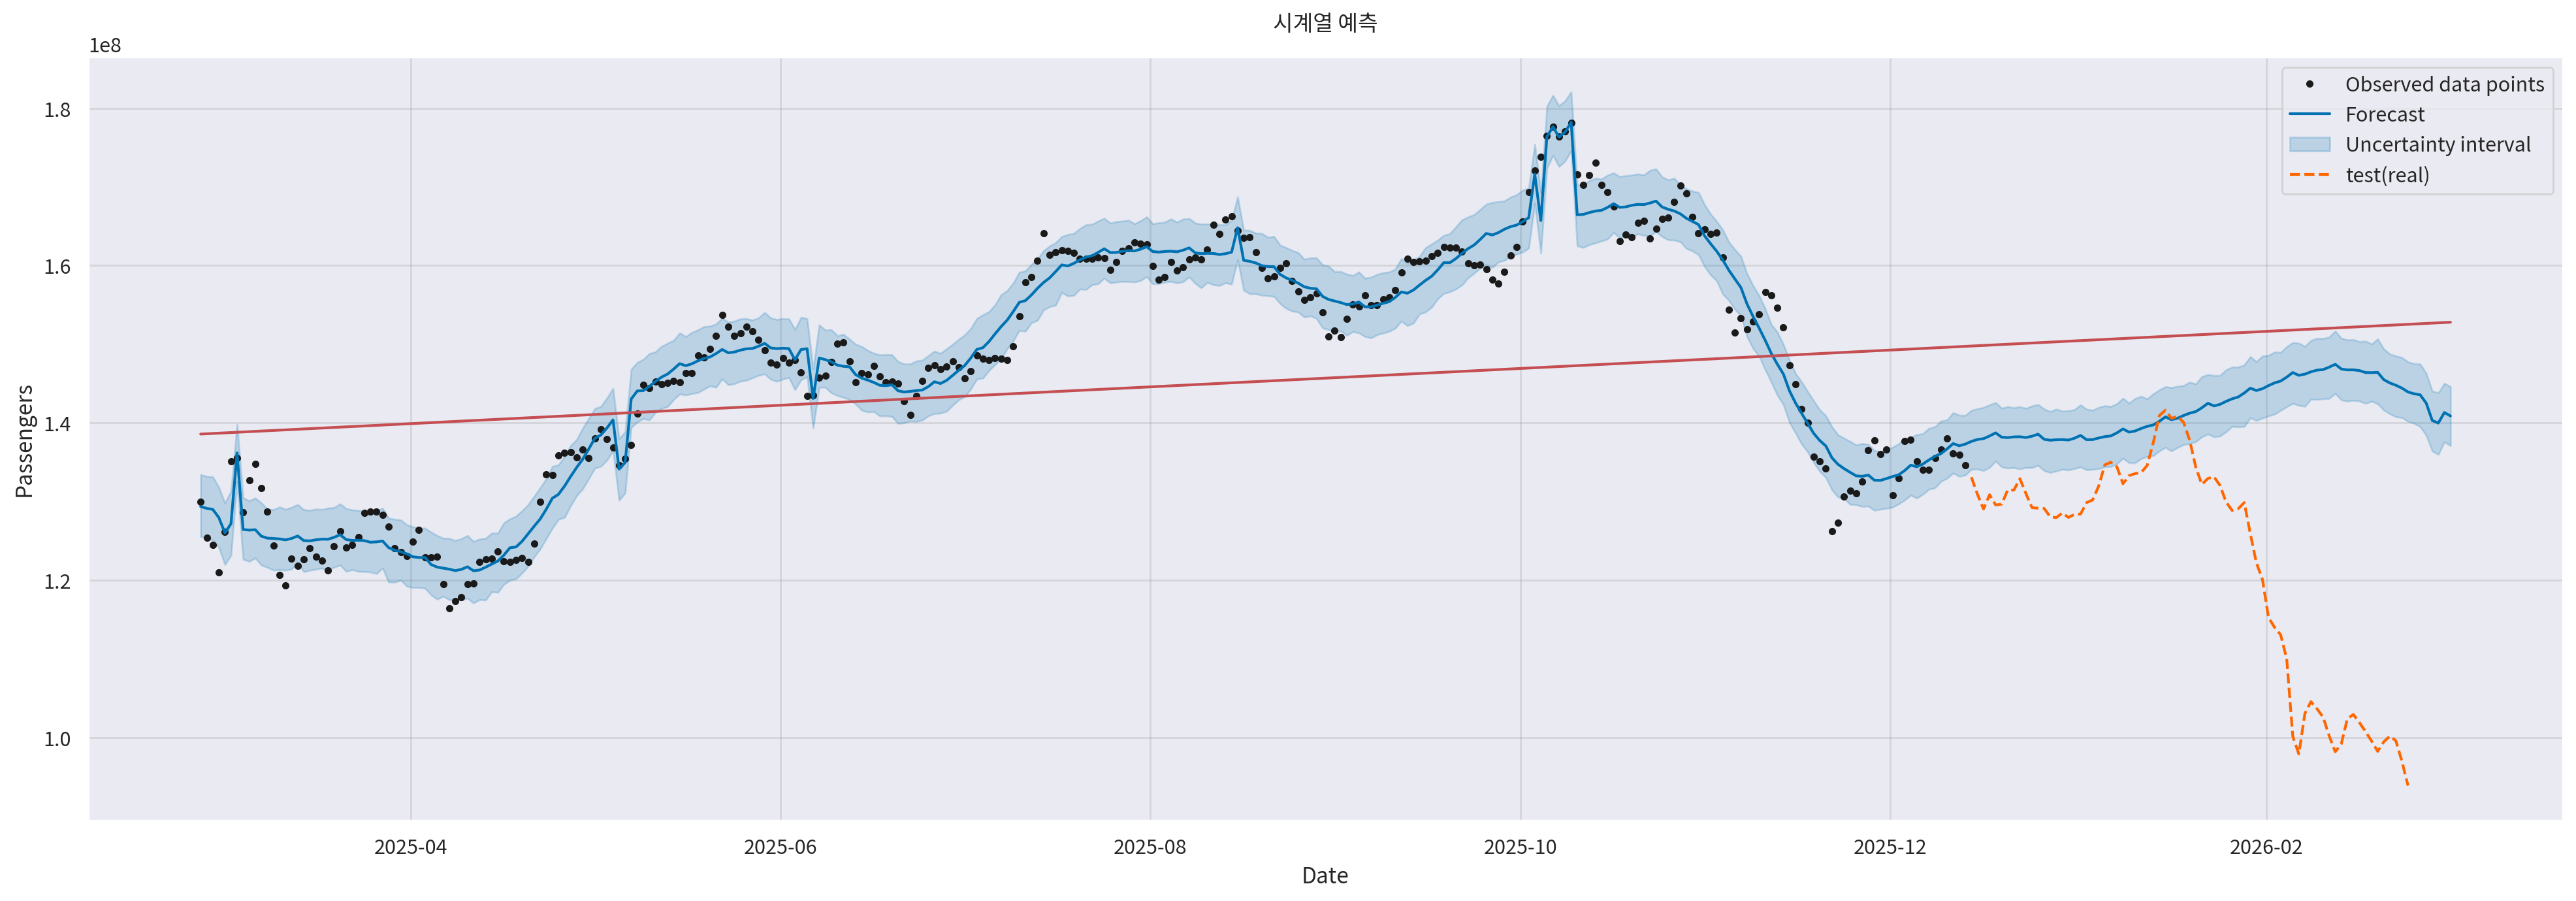

In [17]:
fig = best_model.plot(forecast, figsize=(20, 7), xlabel='Date', ylabel='Passengers', uncertainty=True)
ax = fig.gca()
add_changepoints_to_plot(ax, best_model, forecast)
ax.set_title("시계열 예측")
# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(data=test, x='ds', y='y', ax=ax, color='#ff6600', linestyle="--", label='test(real)')
plt.show()
plt.close()

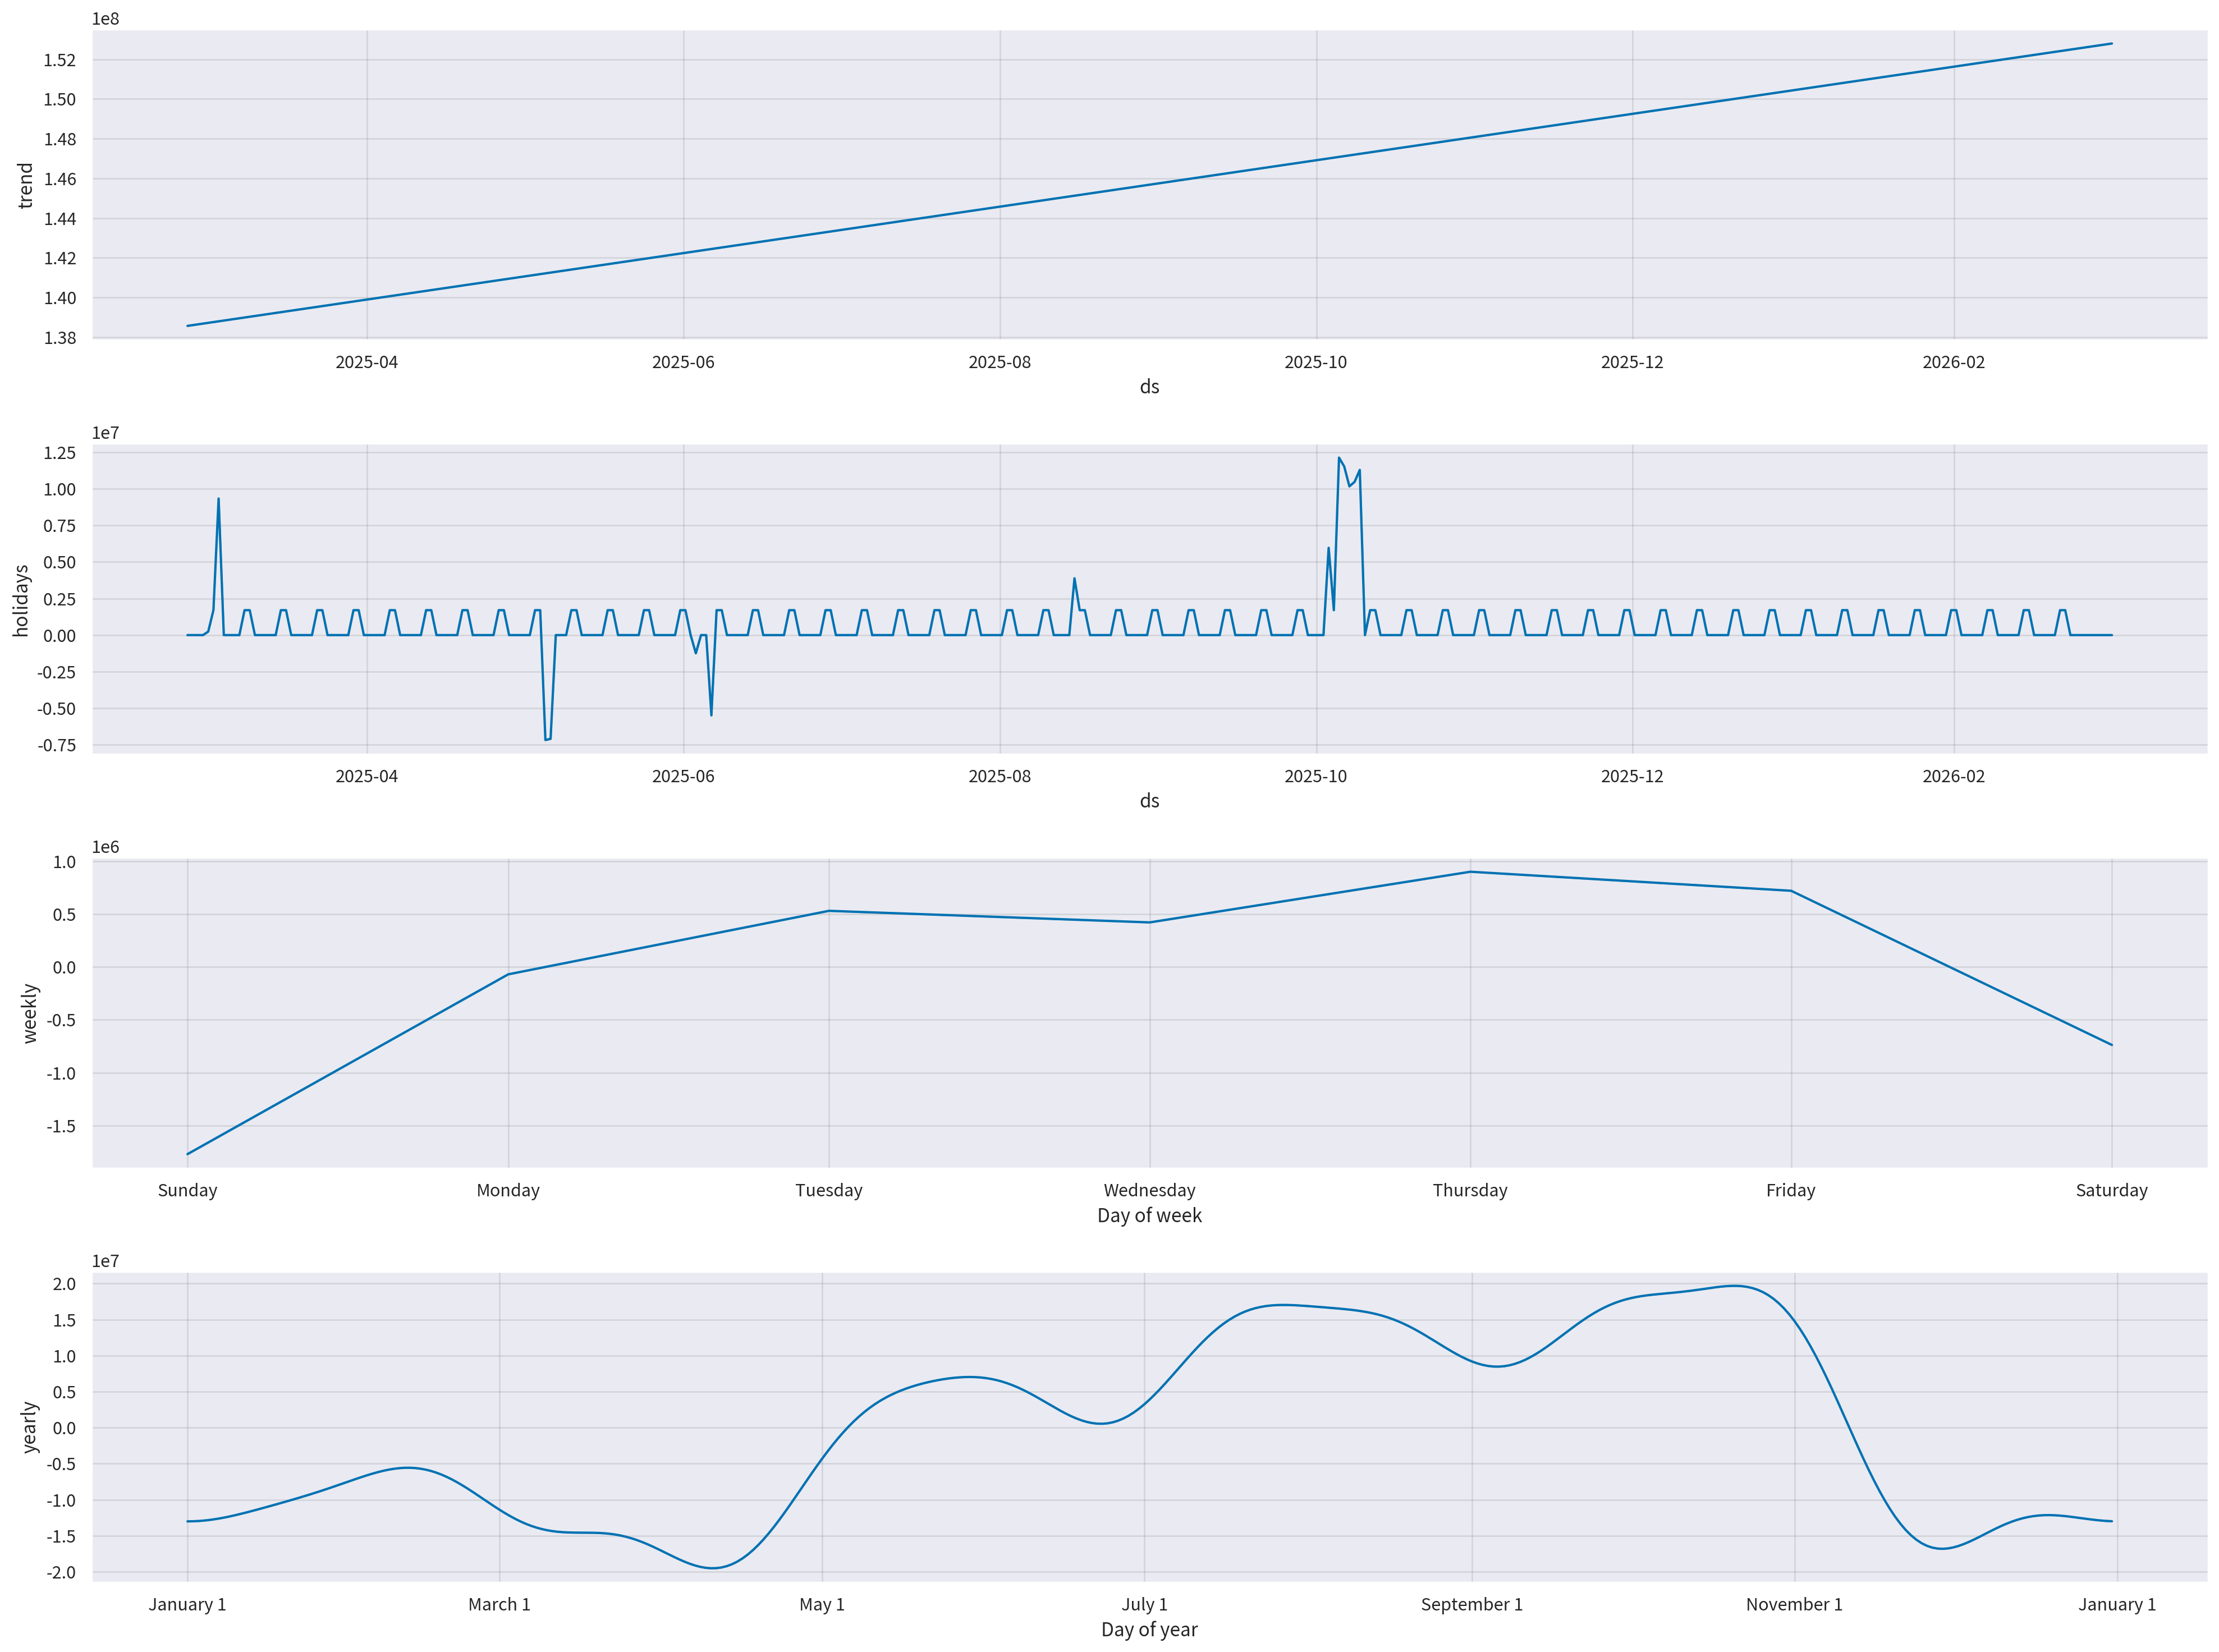

In [18]:
fig = best_model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()